# EDA - Análisis exploratorio de datos: RRHH

**Repaso de todo lo aprendido en el curso**: Lectura de ficheros, pandas (exploración y limpieza) y numpy (operaciones matemáticas), y visualizacion con matplotlib, seaborn y 

## StoryTelling: Contexto

Formáis parte del equipo de análisis de datos del departamento de **Recursos Humanos** de una empresa.

Nos han exportado un extracto de la base de datos de personal (`data/empleados_rrhh.csv`) y dirección os pide un **informe exploratorio** para entender cómo está compuesta la plantilla antes de tomar decisiones (revisión salarial, plan de teletrabajo, etc.).

Como en cualquier dataset real, **los datos no llegan limpios**: habrá nulos, departamentos escritos de formas distintas y filas duplicadas. Vamos a seguir el proceso típico de un EDA:

1. Carga de datos
2. Primera exploración
3. Calidad de datos (nulos, duplicados, inconsistencias)
4. Limpieza
5. Análisis univariante (una variable) + visualización
6. Análisis bivariante (relación entre variables) + visualización
7. Correlación entre variables numéricas
8. Un gráfico interactivo con Plotly
9. Conclusiones

## 0. Importación de librerias y configuracion iniciales.

- revisar que nuestro entorno de desarrollo esta activado y que tenemos todas las librerias instaladas.

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests as rq

sns.set_theme(style="whitegrid")


## 1. Carga de datos
Empezemos siempre igual, los datos o bien viene de base de datos, API, o de un fichero.

In [142]:
df = pd.read_csv('./data/empleados_rrhh.csv')
df.head()

,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
0,79,Beatriz Rubio,Marketing,Hombre,42.0,11.0,32852.78,6.0,18,False
1,151,Ana López,marketing,Hombre,47.0,11.0,36555.44,9.0,1,True
2,172,Teresa Ruiz,ventas,Mujer,52.0,14.0,38518.68,6.0,17,True
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
4,191,Silvia Gómez,VENTAS,Mujer,50.0,14.0,37651.75,5.0,17,True


### 1.1 Inserción de nuevos datos desde n8n

Antes de empezar a limpiar y analizar datos vamos a simular una automatizacion de un ERP de RRHH que envia datos para completar el excel que me pasan.

In [143]:
URL_INSERT_DATA= "https://juanan.n8ncamp.com/webhook/nuevos-empleados"

response = rq.get(URL_INSERT_DATA, timeout=10)
df_nuevos = pd.DataFrame(response.json())

df = pd.concat([df, df_nuevos], ignore_index=True)
print(f"Empleados nuevos incorporados desde n8n {len(df_nuevos)}")
print('Dimension del nuevo dataframe', df.shape)
df.tail()


Empleados nuevos incorporados desde n8n 1000
Dimension del nuevo dataframe (1230, 10)


,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
1225,9995,Félix Castro,RRHH,Hombre,37.0,0.0,37803.68,8.0,2,False
1226,9996,Vanesa Martin,Marketing,Mujer,25.0,1.0,37206.15,7.0,11,True
1227,9997,Francisca Suarez,rrhh,Mujer,50.0,0.0,35857.50,7.0,6,True
1228,9998,Josefa Prieto,marketing,Mujer,28.0,0.0,24417.34,1.0,14,False
1229,9999,Olga Lorenzo,It,Mujer,33.0,0.0,26133.13,7.0,3,False


## 2. Primera exploración
Antes de tocar nada, necesitamos entender qué tenemos entre manos:
    - Cuántas filas
    - Cuántas columnas
    - tipos datos
    - Donde están los valores numéricos

In [144]:
print('Dimensiones (filas, columnas)', df.shape )
df.info()

Dimensiones (filas, columnas) (1230, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_empleado       1230 non-null   int64  
 1   nombre            1230 non-null   str    
 2   departamento      1230 non-null   str    
 3   genero            1230 non-null   str    
 4   edad              1219 non-null   float64
 5   antiguedad_anios  1222 non-null   float64
 6   salario_anual     1051 non-null   float64
 7   satisfaccion      1224 non-null   float64
 8   horas_extra_mes   1230 non-null   int64  
 9   teletrabajo       1230 non-null   bool   
dtypes: bool(1), float64(4), int64(2), str(3)
memory usage: 87.8 KB


Fijaos en dos cosas df.info()
    - Hay columnas con menos valores no nulos que filas totales -> Tenemos valores nulos
    - Comprobar que no hay id_empleado duplicado

### Resumen estadistico: Todas estadisticas tipica, media, mediana, mix, max, cuartiles, etc.

In [145]:
#df.describe()
df['edad'].describe()

count    1219.000000
mean       50.587367
std        16.468147
min        22.000000
25%        36.000000
50%        49.000000
75%        64.000000
max        81.000000
Name: edad, dtype: float64

## 3 Calidad de los datos
Antes limpiar, hay que **detectar** los problemas. Vamos a revisar la cantidad de nulos, duplicados.

In [146]:
# 3.1 Nulos por columna
df.isnull().sum()

id_empleado           0
nombre                0
departamento          0
genero                0
edad                 11
antiguedad_anios      8
salario_anual       179
satisfaccion          6
horas_extra_mes       0
teletrabajo           0
dtype: int64

In [147]:
# 3.2 Filas duplicadas (mismo empleado registrado mas de una vez)
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 10


In [148]:
# 3.3 ¿Cuantos valores distintos tiene "departamento" ? Debría haber solo 5
df['departamento'].value_counts()

departamento
IT            102
Ventas        102
Finanzas       78
Marketing      76
it             65
finanzas       63
rrhh           63
RRHH           62
It             61
Rrhh           58
RRHH           58
MARKETING      56
ventas         54
 Ventas        53
 Marketing     53
Finanzas       50
FINANZAS       48
marketing      43
 IT            43
VENTAS         42
Name: count, dtype: int64

Como sospechábamos: El mismo departamente aparece escrito de varias formas. (IT , it). Esto es muy habitual cuando los datos se han introducido o vienes sistemas distintos.

## 4. Limpieza de datos

4.1 Normalizar la columna Departamento. Quitar espacios en blanco, may y minus

In [149]:
df['departamento'] = df['departamento'].str.strip().str.upper()

# diccionario de traducción con el nombre 'bonito'

nombres_departamento = {
    'IT': 'IT',
    'VENTAS': 'Ventas',
    'MARKETING': 'Marketing',
    'RRHH':'RRHH',
    'FINANZAS': 'Finanzas'
}

df['departamento'] = df['departamento'].replace(nombres_departamento)
df['departamento'].value_counts()


departamento
IT           271
Ventas       251
RRHH         241
Finanzas     239
Marketing    228
Name: count, dtype: int64

4.2 Eliminar duplicados

In [150]:
# ver los datos duplicados

df[df.duplicated(keep=False)]



,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
7,117,Nuria Ortega,Finanzas,Hombre,60.0,2.0,29375.70,6.0,5,False
15,218,Pedro Sánchez,Finanzas,Mujer,60.0,7.0,35328.99,8.0,15,False
16,111,Pedro Álvarez,IT,Mujer,55.0,15.0,43432.72,8.0,18,False
24,192,Marta Gil,Ventas,Hombre,58.0,6.0,21055.33,6.0,10,False
55,48,Marta Delgado,IT,Hombre,50.0,6.0,37401.70,7.0,7,False
61,120,Cristina Pérez,Ventas,Hombre,25.0,13.0,34784.37,8.0,10,False
63,158,Adrián Álvarez,Ventas,Hombre,42.0,2.0,30791.40,5.0,17,False
64,160,Adrián Domínguez,Finanzas,Hombre,40.0,9.0,32802.00,4.0,4,False
71,218,Pedro Sánchez,Finanzas,Mujer,60.0,7.0,35328.99,8.0,15,False


In [151]:
df = df.drop_duplicates()
print('Filas tras eliminar duplicados', len(df))
print('Duplicado restante', df.duplicated().sum())

Filas tras eliminar duplicados 1220
Duplicado restante 0


4.3 Tratar los valores nulos

No todos los valores nulos se tratan igual, depende de la columna y de tipo dato.

 - edad,antiguedad_anios, satisfacción -> los rellenamos con la mediana (es la forma más robusta de estimar un valor "tipico" sin que nos efecte a los extremos)
 - salario_anual -> En lugar de usar la mediana global, usamos la mediana pero solo del departamento. Usamos el groupby para agrupar por departamento
 - nombre, apellidos son susceptibles de eliminarse.

In [152]:
# edad, antigüedad y satisfacción -> mediana global
for columna in ['edad', 'antiguedad_anios', 'satisfaccion']:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana)


# salario -> mediana de todo departamento
df['salario_anual'] = df['salario_anual'].fillna(
    df.groupby('departamento')['salario_anual'].transform('median')
)

# situviesemos que eliminar un registro con valor nulo
#df = df.dropna() # eliminas todos los nulos
# si quisiera eliminar todo lo registro en base a un columna ej: nombre
# df_sin_nulos = df.dropna(subset=['nombre', 'apellidos'])
# si quiero eliminar directamente el campo de df
# df.dropna(subset=['nombre'], inplace=True)

# comprobación final: no deberia quedar ningun nulo
df.isnull().sum()


id_empleado         0
nombre              0
departamento        0
genero              0
edad                0
antiguedad_anios    0
salario_anual       0
satisfaccion        0
horas_extra_mes     0
teletrabajo         0
dtype: int64

## 5. Análisis Univariante

5.1 Empleado por departamento

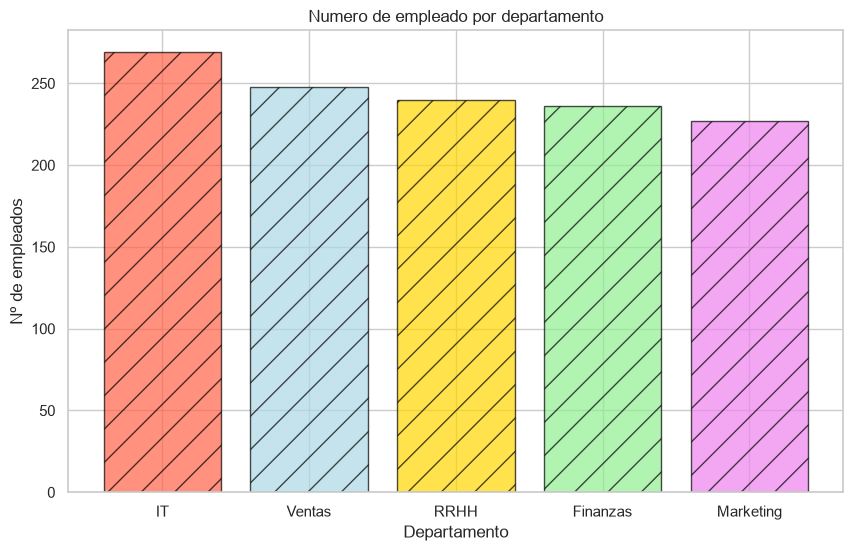

In [153]:
conteo_dpto = df['departamento'].value_counts().reset_index()
conteo_dpto.columns = ['departamento','cantidad']

# matplotlib
plt.figure(figsize=(10,6))
plt.title('Numero de empleado por departamento')
plt.bar(conteo_dpto['departamento'], conteo_dpto['cantidad'], alpha=0.7, edgecolor='black', color=['tomato', 'lightblue', 'gold', 'lightgreen', 'violet'], hatch="/")
plt.xlabel('Departamento')
plt.ylabel('Nº de empleados')
plt.show()


5.2 Distribución de la edad:

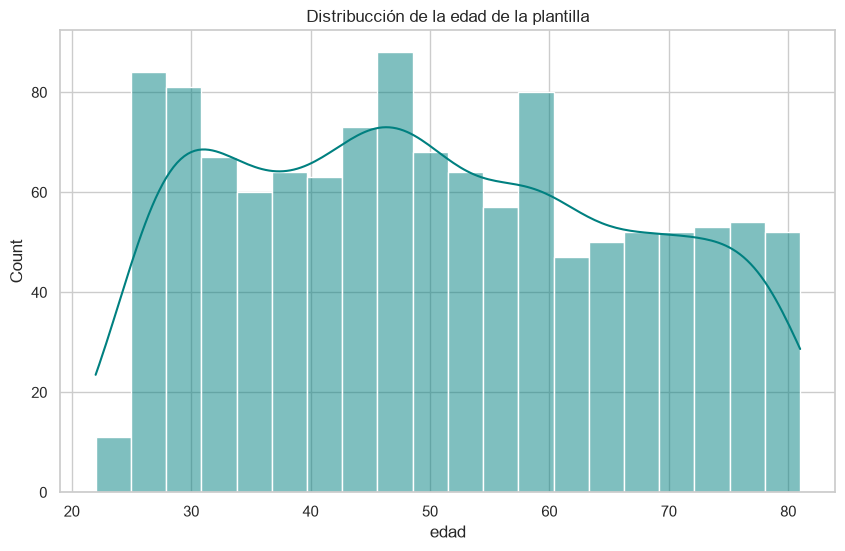

In [154]:
plt.figure(figsize=(10,6))
plt.title('Distribucción de la edad de la plantilla')
sns.histplot(data=df, x='edad', kde=True, color='teal', bins=20)
plt.show()

5.3 Distribución del salario

Vamos a usar boxplot por que nos permite ver la mediana, rango intercuartílico y valores atipicos.

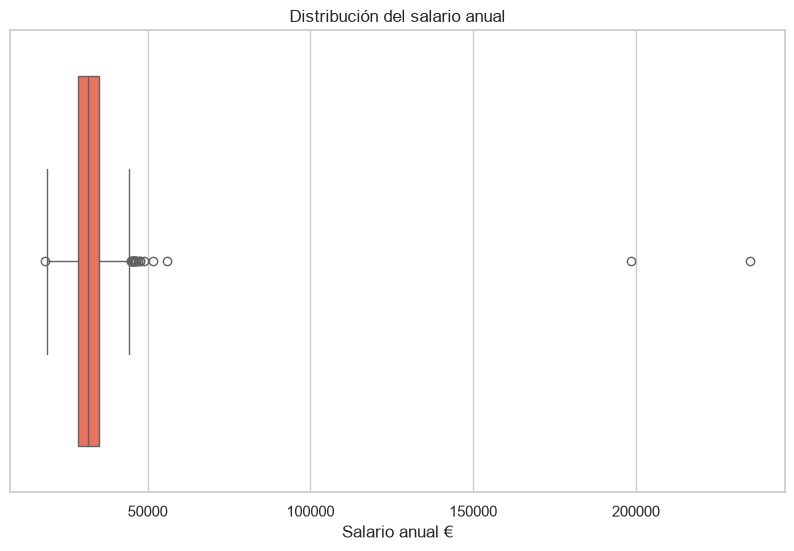

In [155]:
plt.figure(figsize=(10,6))
plt.title('Distribución del salario anual')
sns.boxplot(data=df, x="salario_anual", color='tomato')
plt.xlabel('Salario anual €')
plt.show()

In [156]:
# ¿Quienes son esos salarios outliers que se salen de rango?
df[ df['salario_anual'] > 100000 ][ ['nombre', 'departamento', 'antiguedad_anios', 'salario_anual'] ]

#Salario medio:
int(df['salario_anual'].mean())
# Salario redondea a dos decimales
df['salario_anual'].mean().round(2)


np.float64(32432.63)

5.4 Reparto por genero.

genero
Hombre    625
Mujer     595
Name: count, dtype: int64


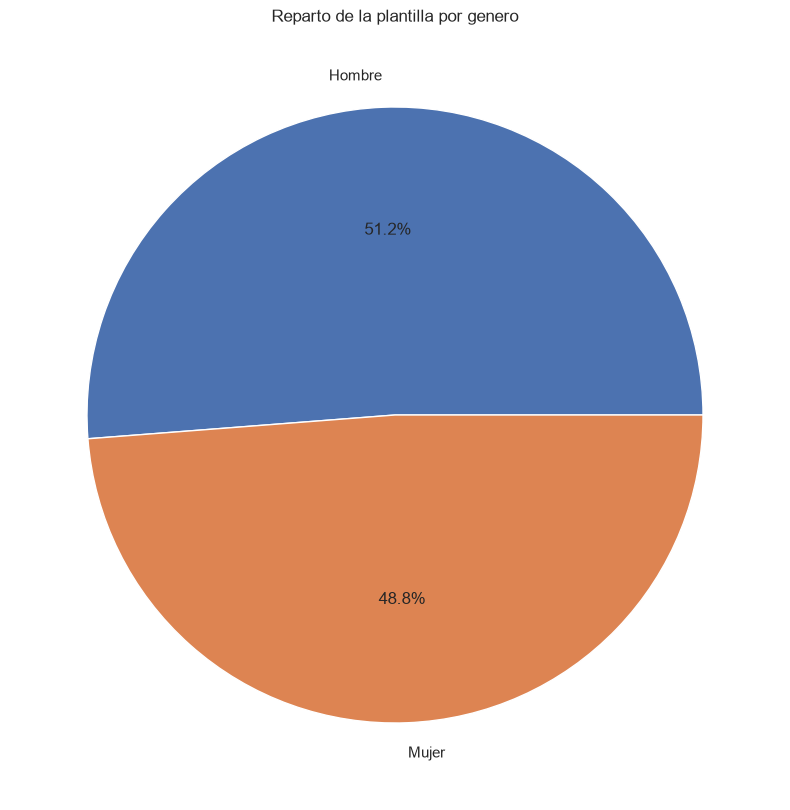

In [157]:
conteo_genero = df['genero'].value_counts()
print(conteo_genero)

plt.figure(figsize=(10, 10))
plt.title('Reparto de la plantilla por genero')
plt.pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct='%1.1f%%'
)
plt.show()

## 6. Análisis Bivariante

Vamos cruzar variables entre si para establecer relaciones.

6.1 Salario medio por departamento.

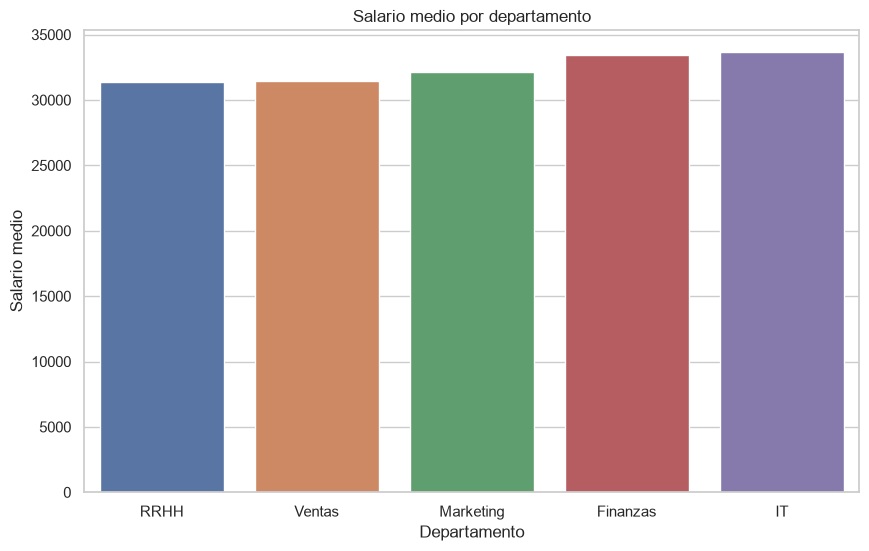

,departamento,salario_anual
3,RRHH,31372.82
4,Ventas,31413.91
2,Marketing,32163.21
0,Finanzas,33454.10
1,IT,33648.57


In [158]:
salario_medio_dpto = (
    df.groupby('departamento')['salario_anual']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('salario_anual', ascending=True)
)

plt.figure(figsize=(10,6))
plt.title('Salario medio por departamento')
sns.barplot(data=salario_medio_dpto, x="departamento", y="salario_anual", hue="departamento", legend=False)
plt.xlabel('Departamento')
plt.ylabel('Salario medio')
plt.show()

salario_medio_dpto

6.2 Relación entre edad y salario

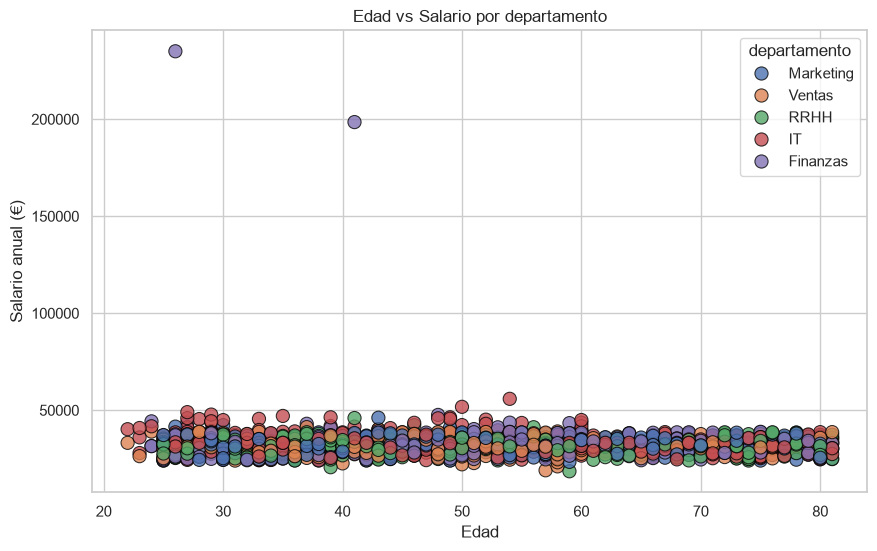

In [159]:
plt.figure(figsize=(10,6))
plt.title('Edad vs Salario por departamento')
sns.scatterplot(data=df, x="edad", y="salario_anual", hue="departamento", s=90, alpha=0.8, edgecolor="black")
plt.xlabel('Edad')
plt.ylabel('Salario anual (€)')
plt.show()

6.3 ¿Influye el teletrabajo en la satisfacción de los trabajadores?

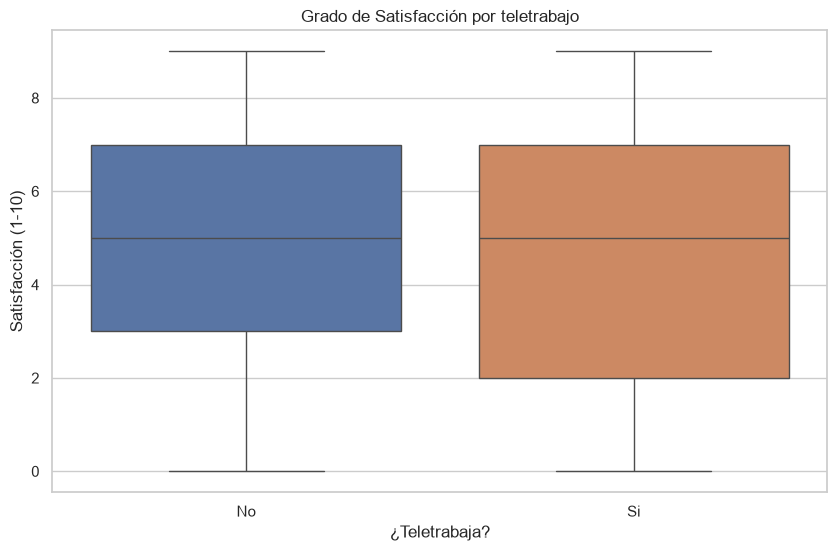

In [160]:
plt.figure(figsize=(10,6))
plt.title('Grado de Satisfacción por teletrabajo')
sns.boxplot(data=df, x="teletrabajo", y="satisfaccion", hue="teletrabajo", legend=False)
plt.xlabel('¿Teletrabaja?')
plt.ylabel('Satisfacción (1-10)')
plt.xticks([False,True],['No', 'Si'])
plt.show()

7. Correlación entre varibles numéricas.
La matriz de correlación nos dice , de un vistazo, que variables numéricas se mueven juntas

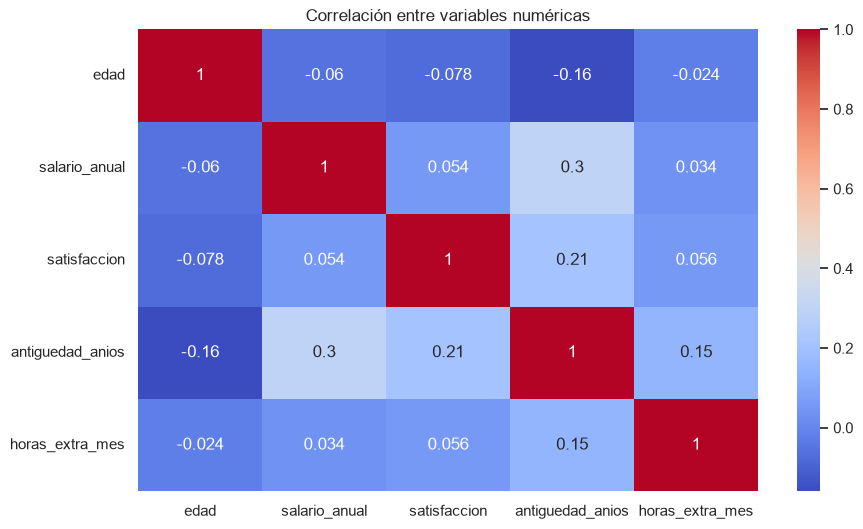

In [161]:
columnas_numericas = ['edad', 'salario_anual', 'satisfaccion', 'antiguedad_anios', 'horas_extra_mes']

matriz_correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(10,6))
plt.title('Correlación entre variables numéricas')
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm')
plt.show()

### 8. Gráfico Interactivo con Plotly

Como ya sabeis con plotly podemos crear el mismo tipo de grafico pero **interactivos**:

In [162]:
fig = px.box(
    df,
    x="departamento",
    y="salario_anual",
    color='departamento',
    points="all",
    title="Distribución del salario por departamento",
    labels={'departamento': 'Departamento', 'salario_anual': 'Salario Anual (€)'}
)

fig.show()

---
## Resumen de funciones utilizadas

| Función / Sintaxis | ¿Para qué sirve? |
|---|---|
| `pd.read_csv()` | Cargar los datos |
| `df.shape` / `df.info()` / `df.describe()` | Primera exploración |
| `df.isnull().sum()` | Contar nulos por columna |
| `df.duplicated()` / `df.drop_duplicates()` | Detectar y eliminar duplicados |
| `df[col].value_counts()` | Distribución de una columna categórica |
| `.str.strip()` / `.str.upper()` / `.replace()` | Normalizar texto |
| `df[col].fillna(valor)` | Rellenar nulos |
| `df.groupby(col).transform()` | Rellenar nulos con un valor por grupo |
| `df.astype()` | Cambiar el tipo de una columna |
| `sns.barplot` / `sns.histplot` / `sns.boxplot` / `sns.scatterplot` / `sns.heatmap` | Visualización estática (seaborn) |
| `plt.pie` | Gráfico de sectores (matplotlib) |
| `df[cols].corr()` | Matriz de correlación |
| `px.box` | Gráfico interactivo (plotly) |
| `requests.get()` / `requests.post()` | Llamar a un webhook de n8n (traer datos / enviar el informe) |

## 9. Conclusiones

Resumen de todos lo que hemos auditado

    - El departamento con concentración de empleados en IT y segundo Ventas.
    - El departamento que tiene el salario medio más alto es el de finanzas y luego IT.
    - El salario medio en esta empresa esta en 37000 €
    - El numero de hombres y mujeres esta bastante compensado cercano a 50%
    - Tenemos un concentración de trabajadores en edad media de entre 37 - 47 años
    - El grado de satisfación no es mucho mayor por el hecho de teletrabajar.
    - Hay dos salarios muy por encima del resto (outliers) que convendría revisar con negocio.
    - Unos de los departamentos más pequeños en cuanto numero de empleados condensa la mayoría de los salarios mas altos.
    - La antigüedad y el salario están ligeramente relacionados a mayor mayor sueldo.
    - El dataset original tenia inconsistencias, datos nulos, formato equivocados que se han tenido que limpiar.

## 10. Enviar el informe automatizado.

In [ ]:
conclusiones = """El departamento con concentración de empleados en IT y segundo Ventas.\nEl departamento que tiene el salario medio más alto es el de finanzas y luego IT.\nEl salario medio en esta empresa esta en 37000 €\nEl numero de hombres y mujeres esta bastante compensado cercano a 50%\nTenemos un concentración de trabajadores en edad media de entre 37 - 47 años\nEl grado de satisfación no es mucho mayor por el hecho de teletrabajar.\nHay dos salarios muy por encima del resto (outliers) que convendría revisar con negocio.\nUnos de los departamentos más pequeños en cuanto numero de empleados condensa la mayoría de los salarios mas altos.\nLa antigüedad y el salario están ligeramente relacionados a mayor mayor sueldo.\nEl dataset original tenia inconsistencias, datos nulos, formato equivocados que se han tenido que limpiar\n
"""
resumen = {
    "fecha_informe": pd.Timestamp.today().strftime('%d-%m-%Y %H:%M'),
    "total_empleados": len(df),
    "salario_medio": float(df['salario_anual'].mean().round(2)),
    "departamento_mas_grande": df['departamento'].value_counts().idxmax(),
    "numero_empleados_departamento_mas_grande":  int(df['departamento'].value_counts().max()),
    "empleados_hacen_teletrabajo": f"{int(df['teletrabajo'].mean() * 100)}%",
    "conclusiones": conclusiones
}

URL_INFORME = "https://juanan.n8ncamp.com/webhook/informe-rrhh"

response = rq.post(URL_INFORME, json=resumen, timeout=10)
print(response.json())



{'status': 'ok', 'message': 'Resumen enviado correctamente'}
